## Tennis Versus (01 - looking at the data carefully)

Here, this begins my journey on training an machine-learning model to predict tennis matches...

For now, I just want to see what the data looks like and do preliminary steps to properly set up the data. I have downloaded tennis match CSV data from 2018 - 2026 (Halle and Queen's just crowned their champions).

Special thanks to: https://stats.tennismylife.org/tennis-match-database

In [23]:
# data analytics + math
import pandas as pd 
import numpy as np 

# data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# other stuff used for later (need sci-kit learn too)
import xgboost # just installed it using !pip install

# set some parameters for pandas to view the data a bit better
pd.set_option('display.max_columns', 50) # see ALL columns
pd.set_option('display.width', 150)

# MERGE all the data together (2018 - current)
# note: the files (in data/ ) are called: 2018.csv, 2019.csv, ... , 2026.csv, ongoing_tourneys.csv
first_try = list(range(2018, 2027))
second_try = list(range(2009, 2027))
csv_files = second_try + ['ongoing_tourneys']
all_dfs = []
for file in csv_files:
    all_dfs.append(pd.read_csv(f"data/{file}.csv"))
df = pd.concat(all_dfs, ignore_index=True) # index[0]: start of 2018 | index[23385]: most recent match

print(df.shape) # wow it has 23,386 matches in total, 2nd try - 50221

print(df.head())

(50221, 50)
  tourney_id tourney_name surface  draw_size tourney_level indoor  tourney_date  match_num winner_id  winner_seed winner_entry         winner_name  \
0   2009-339     Brisbane    Hard       32.0           250      O      20090104        1.0      G858          NaN          NaN      Ernests Gulbis   
1   2009-339     Brisbane    Hard       32.0           250      O      20090104        2.0      M850          NaN          NaN  Paul-Henri Mathieu   
2   2009-339     Brisbane    Hard       32.0           250      O      20090104        3.0      N552          NaN          NaN       Kei Nishikori   
3   2009-339     Brisbane    Hard       32.0           250      O      20090104        4.0      BA47          5.0          NaN       Tomas Berdych   
4   2009-339     Brisbane    Hard       32.0           250      O      20090104        5.0      V306          3.0          NaN   Fernando Verdasco   

  winner_hand  winner_ht winner_ioc  winner_age  winner_rank  winner_rank_points loser_

#### examining data

Now, I will examine the data, specifically I will see if there are any NULL values that will turn out to be problematic.

Also if there any specific matches / rows or categories / columns that just aren't that useful.

##### notable things

- ```surface            53``` - surface is pretty important so what's up with those 53 matches?
  - it seems like theres a handful of Davis Cup group stage matches that are missing this category - probably because they are played at their own venues, so not much data is retrieved there. It's probably a good idea to rid of these matches - they won't affect much.
- ```winner_seed``` ```winner_entry``` (and its loser counterparts) have a huge number of null values...
  - actually, this makes sense because only wildcards, qualifiers, or other special occasions get entry codes
  - also only a small top portion of players in a tournament are seeded, so most players are unseeded. hence, the large amounts of null values there
- ```indoor            1461``` - wow, that's a good chunk of data missing data whether the match was indoors or not!
  - I decided the indoor column as a whole is not useful enough to justify filling in those 1461 cells. Besides, indoor hard vs. outdoor hard isn't too big of a difference anyway.
- serve stats like ```w_ace``` ```w_1stWon``` and ```w_bpSaved``` are all suspiciously missing from ~979 - 990 matches. (?)
  - It's those pesky Davis Cup group stage matches again AND the matches that didn't end in a normal manner.
  - Most of the matches that don't have these serve stats are matches that ended in a walkover ```W/O```, so one of the players retired mid-match because of injury or something.
- ```winner_rank``` ```loser_rank``` is small but sometimes unranked / returning injured players are victorious, so that's fine.
  - I will fill in unranked players with a rank of 2000. (the lowest ranked player I can find is rank 1821)

I will also turn the ```tourney_date``` into actual datetime objects just in case.

In [26]:
print(df.isnull().sum().sort_values(ascending=False))
# print(df[df['surface'].isnull()])
# print(df[df['w_ace'].isnull()][['tourney_name', 'round', 'score']].tail(20))
# print(df[df['winner_rank'].isnull()].tail())

# # removing the 53 weird surface games
# df = df[df['surface'].notna()].reset_index(drop=True)

# # removing the rest of the games that ended abnormally (walkover)
# df = df[df['l_bpSaved'].notna()].reset_index(drop=True)

# # removing indoors column
# df = df.drop(columns=['indoor'])

# # converting to datetime
# df['tourney_date'] = pd.to_datetime(df['tourney_date'], format='%Y%m%d')

# # print(df['winner_rank'].max()) # lowest ranked player

# # filling in unranked players

# df['winner_rank'] = df['winner_rank'].fillna(2000)
# df['loser_rank'] = df['loser_rank'].fillna(2000)
# df['winner_rank_points'] = df['winner_rank_points'].fillna(0)
# df['loser_rank_points'] = df['loser_rank_points'].fillna(0)

# # remove carpet games
# df = df[df['surface'] != 'Carpet'].reset_index(drop=True)


winner_entry          40523
loser_entry           36803
loser_seed            35011
winner_seed           25706
minutes                 712
match_num               486
loser_ht                361
loser_hand              172
winner_ht               121
winner_hand              55
w_SvGms                  12
l_SvGms                  12
loser_age                11
winner_age                8
loser_ioc                 6
winner_ioc                2
loser_id                  1
round                     1
w_2ndWon                  0
w_1stWon                  0
w_1stIn                   0
w_bpSaved                 0
l_ace                     0
w_bpFaced                 0
w_df                      0
l_df                      0
l_svpt                    0
l_1stIn                   0
l_1stWon                  0
l_2ndWon                  0
l_bpSaved                 0
w_svpt                    0
tourney_id                0
w_ace                     0
best_of                   0
score               

### baseline

If we look at JUST the ranks of the players and determine the winners based off only that, we would be right 63.7% of the time.
<br> (that is, if the rank of a player is lower than his opponents, then that guy should probably win)


My model needs to be, at the very least, be better than that.

In [27]:
rate = (df['winner_rank'] < df['loser_rank']).mean() # should be generally true so above 50%

print(f"Baseline accuracy (better rank wins): {rate} or {round(rate*100, 1)}%")

Baseline accuracy (better rank wins): 0.6537869721319883 or 65.4%


### other stats to look at

looking at players who show up frequently and also the surface distribution

In [28]:
match_counts = pd.concat([df['winner_name'], df['loser_name']]).value_counts()

# see the players who have the most data from 2018 - 2026 current
match_counts.head(11)

Novak Djokovic      1134
Rafael Nadal         890
Marin Cilic          844
Grigor Dimitrov      776
Alexander Zverev     775
Andy Murray          765
Stan Wawrinka        752
Gael Monfils         751
Fabio Fognini        742
Richard Gasquet      741
Roger Federer        739
Name: count, dtype: int64

surface
Hard     27073
Clay     14591
Grass     5128
Name: count, dtype: int64


<Axes: xlabel='surface'>

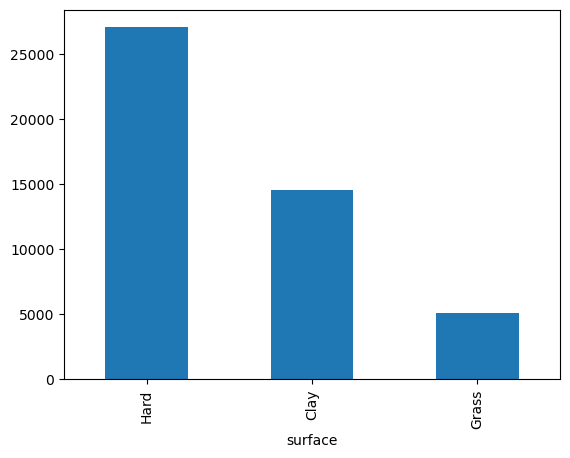

In [29]:
s = df['surface'].value_counts()
print(s)

s.plot(kind='bar')

### we are done (for now)

we will save this DataFrame and use it in the next notebook.

In [30]:


# turn some columns into numeric types so we can save it as a parquet file
df['l_bpFaced'] = pd.to_numeric(df['l_bpFaced'], errors='coerce')
df['loser_seed'] = pd.to_numeric(df['loser_seed'], errors='coerce')

# tourney level is 250, 500, G - grand slam, M - masters
# so turn everything into a string
df['tourney_level'] = df['tourney_level'].astype(str)
df['tourney_level'] = df['tourney_level'].replace('nan', pd.NA) # turning all the stringified NaNs into actual NaNs

# finally, save it into a parquet file 
df.to_parquet('cleaned_matches_01done.parquet')
